# Exercício 1

Todo número real $x \in [0,1]$ pode ser representado, ou aproximado, por meio de uma **decomposição binária**. Nessa representação, utilizamos apenas os dígitos 0 e 1.

Considerando os primeiros $D$ dígitos binários, podemos escrever

$$
x = \frac{b_1}{2} + \frac{b_2}{2^2} + \frac{b_3}{2^3} + \cdots + \frac{b_D}{2^D},
$$

em que cada $b_i \in \{0,1\}$.

Por exemplo, o número binário $0.101_2$ corresponde, na base decimal, a

$$
0.101_2
=
1\cdot\frac{1}{2}
+
0\cdot\frac{1}{2^2}
+
1\cdot\frac{1}{2^3}
=
0.625.
$$

Assim, ao gerar aleatoriamente uma sequência de zeros e uns, podemos utilizá-la como os dígitos de uma expansão binária e, dessa forma, construir números aleatórios no intervalo $[0,1]$.


Utilizando a função `np.random.choice`, gere uma sequência de tamanho $D$ composta por dígitos 0 ou 1.

1. Utilizando essa sequência e um laço `for`, construa um número aleatório entre 0 e 1 a partir de sua decomposição binária, conforme descrito acima.

2. Utilizando a função `np.arange`, repita o procedimento do item anterior **sem utilizar um laço `for`**. Faça o cálculo por meio de operações vetorizadas, utilizando a multiplicação termo a termo entre os dígitos binários e as respectivas potências de $1/2$.

3. Utilizando o procedimento vetorizado desenvolvido no item 2, gere uma amostra de tamanho $N$ de números aleatórios no intervalo $[0,1]$. Em seguida, gere outra amostra de mesmo tamanho utilizando a função `np.random.uniform`. Compare as distribuições das duas amostras por meio de histogramas e discuta se o procedimento baseado na decomposição binária produz resultados compatíveis com uma distribuição uniforme.

4. Repita o passo 3 várias vezes com diferentes valores de $D$ e comente qual o efeito de aumentar ou diminuir $D$.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1.1

In [2]:
TAMANHO = 1000

num_bin = np.random.choice(a=(0,1), size=TAMANHO)

valor = 0
for i, dado in enumerate(num_bin):
    valor += dado*((1/2)**(i+1))    

print(valor)


0.22339492796039473


Aqui, eu gerei um vetor com zeros e ums, e depois utilizei um loop para utilizar a decomposição binária (elevando 1/2 a potências naturais) e multiplicando por cada valor do vetor (dado) e somando, para obter o número entre 0 e 1

### 1.2

In [3]:
binarizacao = (1/2)**np.arange(1,TAMANHO+1)
vetor_ultimo = binarizacao*num_bin

print(np.sum(vetor_ultimo))
print(np.sum((1/2)**np.arange(1,TAMANHO+1)*num_bin))

0.22339492796039473
0.22339492796039473


Aqui eu criei a variável "binarizacao" para criar um vetor com as potências naturais de 0.5, mas como o arange vai ate um valor antes, precisamos colocar TAMANHO+1.
Também criei o "vetor_ultimo" que multiplica, entrada por entrada, a potencia de 0.5 do vetor "binarizacao" por o vetor "num_bin", que tem valores 0 ou 1.
Por fim, somei o "vetor_ultimo" para obter valor entre 0 e 1. Preferi criar váriaveis desse jeito ao invés de colocar o print com tudo dentro de uma vez para ficar mais organizado os passos

### 1.3

(array([ 988., 1009.,  961.,  966., 1031.,  974., 1045.,  993., 1019.,
        1014.]),
 array([6.18075939e-05, 1.00049343e-01, 2.00036879e-01, 3.00024414e-01,
        4.00011949e-01, 4.99999485e-01, 5.99987020e-01, 6.99974556e-01,
        7.99962091e-01, 8.99949627e-01, 9.99937162e-01]),
 <BarContainer object of 10 artists>)

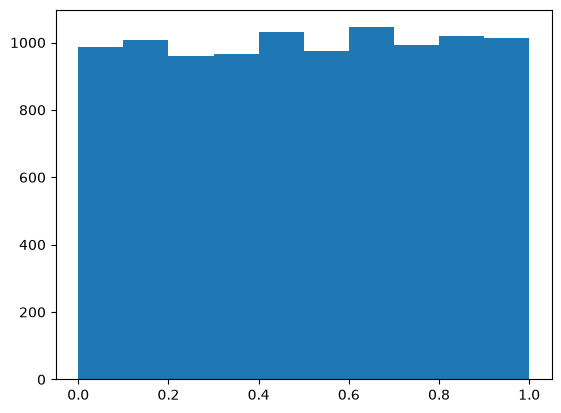

In [4]:
amostra_final = []

for i in range(10000):
    num_bin = np.random.choice(a=(0,1), size=TAMANHO)
    num = np.sum((1/2)**np.arange(1,TAMANHO+1)*num_bin)
    amostra_final.append(num)


plt.hist(amostra_final)

Aqui eu utilizei um for para gerar uma amostra de valores entre 0 e 1 e adicioná-los na lista "amostra_final", depois disso, apenas plotei um histograma da minha amostra

(array([1022.,  995.,  996.,  993.,  989., 1024., 1068.,  992.,  981.,
         940.]),
 array([9.94916928e-05, 1.00087857e-01, 2.00076222e-01, 3.00064587e-01,
        4.00052953e-01, 5.00041318e-01, 6.00029683e-01, 7.00018048e-01,
        8.00006414e-01, 8.99994779e-01, 9.99983144e-01]),
 <BarContainer object of 10 artists>)

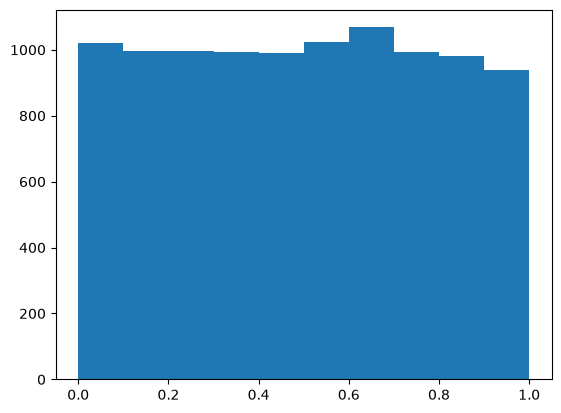

In [5]:
amostra_pela_funcao = np.random.uniform(low=0, high=1, size=10000)
plt.hist(amostra_pela_funcao)

Aqui eu só utilizei a funcao np.random.uniform e plotei o histograma. Percebe-se que os histogramas são parecidos, o que mostra que ambos os métodos geram resultados satisfatórios

# Exercício 2 — Simulação de variáveis aleatórias a partir da distribuição uniforme

Apesar de o exercício anterior mostrar como podemos gerar variáveis uniformes em $[0,1]$ a partir de lançamentos de moedas, a partir de agora, e ao longo do curso, assumiremos que o único mecanismo de geração de números aleatórios disponível é a geração de variáveis uniformes no intervalo $[0,1]$.

Neste exercício, vamos utilizar variáveis uniformes para simular algumas das variáveis aleatórias discretas vistas em sala.

A ideia fundamental será transformar uma variável

$$
U \sim \text{Uniforme}(0,1)
$$

em outra variável aleatória por meio de uma função apropriada.

Em todos os itens, considere uma amostra de tamanho $N$.

## 1. Gerando a amostra uniforme

Utilizando `np.random.uniform`, gere uma amostra

$$
U_1,\ldots,U_N
$$

de variáveis aleatórias independentes com distribuição uniforme em $[0,1]$.

Essa será a única fonte de aleatoriedade utilizada nos itens seguintes.

In [6]:
uniforme = np.random.uniform(size=1000)
uniforme

array([0.65628812, 0.28635874, 0.10861614, 0.61558621, 0.61779298,
       0.07519252, 0.42767645, 0.93591917, 0.73287536, 0.71765182,
       0.32513419, 0.83278204, 0.13609097, 0.93275778, 0.31666266,
       0.36505688, 0.94426033, 0.79718711, 0.60114854, 0.02797506,
       0.98059401, 0.16587218, 0.7286896 , 0.44182744, 0.62019962,
       0.11648255, 0.94458413, 0.9187493 , 0.67812183, 0.91318561,
       0.52269491, 0.78436647, 0.64524959, 0.23458869, 0.35862731,
       0.61212014, 0.24864706, 0.42793214, 0.93152531, 0.88345648,
       0.60573089, 0.57648478, 0.13061828, 0.6936604 , 0.07788248,
       0.83986088, 0.70234641, 0.75127849, 0.18186081, 0.35146691,
       0.41195947, 0.51005072, 0.06984972, 0.10380781, 0.07910361,
       0.43970046, 0.00578393, 0.33448366, 0.17930398, 0.55486498,
       0.55199074, 0.08390661, 0.52497691, 0.67456268, 0.95403696,
       0.65190202, 0.5551136 , 0.07146793, 0.93908586, 0.60383073,
       0.05695998, 0.14771533, 0.60176985, 0.71316746, 0.25138

Apenas gerei uma amostra uniforme de tamanho 1000

## 2. Variável Bernoulli

Considere uma variável aleatória Bernoulli com parâmetro $p$, isto é,

$$
P(X=1)=p
\qquad \text{e} \qquad
P(X=0)=1-p.
$$

Utilizando a amostra uniforme gerada no item anterior:

1. Gere uma amostra Bernoulli utilizando um `for` e uma estrutura `if/else`.

2. Crie uma função `f` que transforme valores uniformes em valores `0` ou `1` de acordo com o parâmetro $p$. Em seguida, aplique diretamente essa função à amostra uniforme, isto é, `f(amostra)`.

3. Calcule a média e a variância da amostra Bernoulli obtida e compare-as com os valores teóricos

$$
\mathbb{E}[X]=p
\qquad \text{e} \qquad
\operatorname{Var}(X)=p(1-p).
$$

### 2.1

In [10]:
prob_sucesso = 0.60
n = 50
bernoulli = []

for i in range(n):
    U = np.random.uniform(low=0, high=1)
    if U > prob_sucesso:
        bernoulli.append(0)
    else:
        bernoulli.append(1)

print(bernoulli)
print(np.mean(bernoulli))

[1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1]
0.64


Aqui eu gerei uma amostra bernoulli a partir de numeros entre 0 e 1. Se o número gerado for menor que a probabilidade, consideramos sucesso, e portanto, 1. Caso contrário, se o número gerado entre 0 e 1 for maior que a probabilidade, considera-se fracasso, e portanto 0. Além disso, eu fui adicionando os valores da bernoulli em uma lista

### 2.2

In [11]:
def f(amostra,parametro):
    lista = []
    for num in amostra:
        if num < parametro:
            lista.append(1)
        else:
            lista.append(0)
    return lista
    
    

In [12]:
U = np.random.uniform(low=0, high=1,size=100)
amostra_bernoulli = f(U,0.8)
print(amostra_bernoulli)

[1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1]


Aqui eu basicamente fiz a mesma coisa do item anterior, mas dentro de uma função

### 2.3

In [17]:
media_amostra_bernoulli = np.mean(amostra_bernoulli)
variancia_amostra_bernoulli = np.var(amostra_bernoulli)

media_teorica_bernoulli = 0.8
variancia_teorica_bernoulli = 0.8*0.2

print(f' A média amostral da amostra bernoulli foi de {media_amostra_bernoulli}, e a média teórica é de {media_teorica_bernoulli}')
print(f' A variância amostral da  mostra bernoulli foi de {variancia_amostra_bernoulli}, e a variância teórica é de {variancia_teorica_bernoulli:.2f}')


 A média amostral da amostra bernoulli foi de 0.82, e a média teórica é de 0.8
 A variância amostral da  mostra bernoulli foi de 0.1476, e a variância teórica é de 0.16


Como podemos perceber, a média amostral foi 0.79, que é muito próximo da média teórica (0.8), e a variância amostral foi de 0.1659, também muito próximo da variância teórica, que é 0.16  (esses cálculos consideraram a bernoulli com parâmetro 0.8)

## 3. Lançamento de um dado justo

Considere um dado justo de seis faces, de modo que

$$
P(X=k)=\frac{1}{6}, \qquad k=1,\ldots,6.
$$

Utilizando a amostra uniforme gerada no item 1:

1. Gere uma amostra de lançamentos do dado utilizando um `for` e uma estrutura `if/elif/else`.

2. Crie uma função `f` que transforme valores uniformes em valores de `1` a `6`. Em seguida, aplique diretamente a função à amostra uniforme, isto é, `f(amostra)`.

3. Você consegue encontrar uma forma mais simples de fazer essa transformação, sem utilizar `if/elif/else`? Pense no que acontece ao multiplicar um valor uniforme por 6 e considerar apenas sua parte inteira.

4. Calcule a frequência relativa de cada face e compare-a com o valor teórico $1/6$.

5. Calcule a média e a variância da amostra e compare-as com os valores teóricos: $\mathbb{E}[X], \operatorname{Var}(X).$ Você pode calcular usando a fórmula $\operatorname{Var}(X) = \mathbb{E}[X^2] - \mathbb{E}[X]^2$.

6. Repita o procedimento anterior para um dado viciado com probabilidades

$$
P(X=1)=0.05,\quad
P(X=2)=0.10,\quad
P(X=3)=0.15,
$$

$$
P(X=4)=0.20,\quad
P(X=5)=0.20,\quad
P(X=6)=0.30.
$$

Construa uma função `f` que transforme a amostra uniforme em lançamentos desse dado. Compare as frequências relativas obtidas com as probabilidades teóricas acima e compare também a média e a variância amostrais com os valores teóricos.


### 3.1

In [21]:
amostra_dados = []
n = 100

for i in range(n):
    U = np.random.uniform(low=0, high=1)
    if U < 1/6:
        amostra_dados.append(1)
    elif U < 2/6:
        amostra_dados.append(2)
    elif U < 3/6:
        amostra_dados.append(3)
    elif U < 4/6:
        amostra_dados.append(4)
    elif U < 5/6:
        amostra_dados.append(5)
    elif U < 1:
        amostra_dados.append(6)


print(amostra_dados) 


[3, 1, 5, 4, 5, 4, 6, 1, 6, 3, 3, 1, 3, 5, 3, 4, 2, 1, 2, 6, 2, 2, 3, 4, 1, 5, 6, 2, 2, 2, 5, 4, 6, 2, 6, 2, 2, 1, 5, 1, 1, 1, 1, 3, 4, 6, 2, 3, 1, 5, 4, 6, 6, 5, 1, 4, 6, 5, 2, 6, 2, 4, 3, 2, 4, 2, 4, 6, 3, 5, 1, 1, 1, 1, 6, 2, 6, 1, 3, 1, 6, 1, 5, 5, 3, 3, 5, 2, 4, 6, 4, 1, 5, 4, 6, 1, 4, 6, 4, 5]


Aqui eu segui a mesma lógica da bernoulli mas, o que mudou foi que eu separei o intervalo de 0 a 1 em partes iguais, de forma a ter 6 intervalos, simulando um dado (com lados 1,2,3,4,5,6)  

### 3.2

In [22]:
def gerar_dados_dado(amostra_uniforme):
    amostra_dados = []
    for i in amostra_uniforme:
        if i < 1/6:
            amostra_dados.append(1)
        elif i < 2/6:
            amostra_dados.append(2)
        elif i < 3/6:
            amostra_dados.append(3)
        elif i < 4/6:
            amostra_dados.append(4)
        elif i < 5/6:
            amostra_dados.append(5)
        else:
            amostra_dados.append(6)
    return amostra_dados

amostra = np.random.uniform(low=0,high=1,size=1000)
print(gerar_dados_dado(amostra))

[5, 3, 5, 2, 4, 2, 3, 5, 4, 6, 4, 6, 5, 2, 1, 4, 5, 5, 2, 3, 4, 6, 2, 6, 5, 1, 4, 4, 5, 6, 6, 6, 4, 5, 5, 6, 5, 4, 6, 5, 5, 5, 1, 4, 4, 1, 1, 3, 3, 6, 6, 1, 3, 5, 4, 6, 2, 1, 3, 5, 4, 1, 4, 6, 5, 1, 3, 6, 3, 3, 4, 3, 6, 3, 3, 2, 2, 4, 5, 3, 4, 2, 1, 2, 6, 4, 4, 3, 1, 2, 1, 6, 2, 4, 6, 5, 4, 1, 5, 1, 5, 5, 3, 4, 4, 6, 3, 3, 2, 4, 6, 2, 1, 1, 4, 5, 1, 3, 4, 5, 6, 5, 6, 1, 5, 1, 2, 2, 5, 2, 4, 1, 4, 6, 2, 2, 2, 3, 2, 2, 5, 3, 3, 3, 5, 3, 1, 2, 4, 5, 1, 2, 5, 4, 6, 2, 5, 5, 1, 4, 2, 1, 5, 5, 1, 6, 4, 4, 1, 1, 6, 2, 1, 1, 5, 6, 1, 3, 4, 3, 6, 3, 3, 1, 1, 4, 2, 5, 5, 1, 2, 3, 1, 1, 1, 2, 6, 3, 2, 3, 5, 1, 3, 2, 5, 5, 3, 3, 4, 5, 2, 5, 5, 3, 5, 3, 6, 6, 6, 2, 4, 4, 6, 4, 5, 4, 1, 6, 6, 3, 5, 6, 6, 4, 6, 4, 1, 5, 4, 2, 1, 6, 2, 3, 3, 1, 3, 2, 2, 1, 5, 4, 2, 4, 3, 5, 3, 1, 4, 1, 5, 6, 1, 4, 5, 2, 4, 3, 6, 3, 1, 2, 4, 3, 6, 5, 3, 3, 2, 6, 6, 4, 6, 3, 4, 3, 2, 1, 4, 5, 4, 4, 6, 5, 5, 6, 2, 4, 2, 2, 5, 3, 5, 1, 6, 2, 2, 5, 5, 5, 3, 1, 6, 3, 6, 3, 2, 5, 4, 1, 6, 4, 5, 6, 3, 2, 2, 4, 4, 4, 4, 4, 5, 

Aqui eu só segui a ideia do item anterior e criei uma função que calcular os valores do dado a partir de uma uniforme de tamanho N de dados.

### 3.3

In [23]:
amostra_uniforme = np.random.uniform(low=0,high=1,size=1000)
amostra_uniforme_6 = amostra_uniforme*6 
amostra_uniforme_arredondada = np.ceil(amostra_uniforme_6)
print(f'A amostra dos dados é\n {amostra_uniforme_arredondada}')



A amostra dos dados é
 [6. 6. 1. 5. 5. 1. 5. 5. 3. 4. 2. 3. 5. 2. 6. 3. 4. 4. 1. 5. 4. 6. 5. 2.
 2. 1. 1. 2. 4. 4. 5. 6. 5. 2. 6. 6. 3. 5. 2. 6. 1. 6. 6. 1. 2. 3. 3. 2.
 6. 3. 5. 3. 3. 1. 1. 2. 3. 5. 1. 2. 3. 1. 3. 1. 5. 6. 4. 1. 2. 2. 6. 4.
 6. 6. 2. 1. 5. 2. 6. 2. 6. 2. 2. 4. 1. 3. 6. 1. 2. 3. 4. 5. 5. 3. 4. 3.
 3. 3. 5. 6. 6. 1. 2. 5. 3. 4. 6. 2. 5. 4. 1. 3. 3. 2. 6. 2. 5. 5. 1. 1.
 4. 1. 1. 1. 5. 6. 5. 5. 4. 6. 1. 2. 5. 2. 6. 3. 6. 4. 6. 1. 3. 4. 5. 1.
 4. 2. 6. 1. 5. 5. 5. 1. 2. 6. 4. 2. 4. 3. 6. 5. 5. 1. 4. 5. 3. 1. 5. 6.
 6. 2. 5. 3. 3. 5. 2. 3. 1. 5. 3. 3. 4. 5. 4. 3. 6. 5. 6. 4. 2. 5. 2. 6.
 4. 1. 4. 1. 6. 3. 2. 6. 2. 4. 6. 4. 5. 6. 5. 2. 3. 1. 4. 1. 4. 5. 3. 1.
 4. 4. 5. 3. 2. 2. 4. 4. 6. 5. 6. 5. 5. 2. 5. 4. 5. 3. 6. 3. 1. 1. 6. 1.
 2. 3. 1. 2. 5. 2. 3. 5. 6. 2. 2. 4. 1. 6. 3. 6. 3. 2. 2. 3. 1. 2. 2. 4.
 1. 1. 5. 3. 2. 6. 2. 1. 4. 3. 6. 3. 6. 4. 3. 3. 2. 5. 4. 6. 2. 5. 1. 2.
 5. 6. 1. 1. 1. 5. 6. 3. 2. 1. 1. 5. 1. 6. 5. 1. 6. 5. 6. 1. 6. 5. 5. 5.
 2. 1. 4. 6. 5. 5. 5. 2. 2. 

### 3.4

In [25]:
np.unique(amostra_uniforme_arredondada,return_counts=True)

(array([1., 2., 3., 4., 5., 6.]), array([179, 149, 167, 157, 172, 176]))

In [24]:
faces, frequencia_absoluta =  np.unique(amostra_uniforme_arredondada,return_counts=True)
frequencia_relativa = frequencia_absoluta/1000
frequencia_relativa

array([0.179, 0.149, 0.167, 0.157, 0.172, 0.176])

As frequências relativas estão entre 0.183 e 0.149, o que é bem perto do valor teórico, que é 1/6 (0,166666...)

### 3.5

In [29]:
dados = np.arange(1,7)

media_amostral = np.mean(amostra_uniforme_arredondada)
variancia_amostral = np.var(amostra_uniforme_arredondada)

media_teorica = np.mean(dados)
Ex2 = np.sum(dados**2)/6
Ex_ao_quadrado = media_teorica**2
var = Ex2 - Ex_ao_quadrado


print(f'A média teórica é: {media_teorica}. Já a média amostral é {media_amostral}')
print(f'A variância teórica é: {var}. Já a variância amostral é: {variancia_amostral}')

A média teórica é: 3.5. Já a média amostral é 3.522
A variância teórica é: 2.916666666666666. Já a variância amostral é: 3.021516


Aqui eu apenas calculei a média e a variância teórica e amostral, e elas são muito parecidas, como esperado.

### 3.6

In [30]:
def gerar_dados_dado_viciado(amostra_uniforme):
    amostra_dados = []
    for i in amostra_uniforme:
        if i < 5/100:
            amostra_dados.append(1)
        elif i < 15/100:
            amostra_dados.append(2)
        elif i < 30/100:
            amostra_dados.append(3)
        elif i < 50/100:
            amostra_dados.append(4)
        elif i < 70/100:
            amostra_dados.append(5)
        else:
            amostra_dados.append(6)
    return amostra_dados


In [31]:
amostra_normal = np.random.uniform(low=0,high=1,size=10)
amostra_viciada = gerar_dados_dado_viciado(amostra_normal)
print(amostra_viciada)

[6, 3, 5, 4, 5, 3, 3, 2, 3, 6]


Aqui eu apenas repeti o processo para o dado viciado

## 4. Distribuição Binomial

Podemos interpretar uma variável aleatória binomial pensando em lançamentos de uma moeda. Suponha que lançamos uma moeda $n$ vezes, de forma independente, e que a probabilidade de obter **cara** em cada lançamento seja $p$.

Se contarmos o número total de caras obtidas nesses $n$ lançamentos, esse número segue uma distribuição binomial:

$$
X \sim \mathrm{Binomial}(n,p).
$$

Assim, uma variável binomial nada mais é do que a soma de $n$ variáveis Bernoulli independentes:

$$
X = X_1 + \cdots + X_n,
\qquad
X_i \sim \mathrm{Bernoulli}(p),
$$

onde $X_i=1$ representa uma cara e $X_i=0$ representa uma coroa.

1. Utilizando o procedimento desenvolvido anteriormente para gerar variáveis Bernoulli, gere uma amostra de tamanho $N$ de variáveis com distribuição $\mathrm{Binomial}(n,p)$.

2. Calcule a média e a variância da amostra e compare-as com os valores teóricos

$$
\mathbb{E}[X]=np
\qquad \text{e} \qquad
\operatorname{Var}(X)=np(1-p).
$$

3. Gere uma segunda amostra de tamanho $N$ utilizando `np.random.binomial` com os mesmos parâmetros $n$ e $p$. Compare as duas amostras por meio de histogramas.


### 4.1

In [47]:
amostra_de_binomiais = []
prob = 0.5
binomial = 0

for j in range(10):
    binomial = 0
    bernoulli = []
    for i in range(100):
        U = np.random.uniform(low=0, high=1)
        if U < prob:
            bernoulli.append(1)
            binomial += 1
        else:
            bernoulli.append(0)
    amostra_de_binomiais.append(binomial)

print(binomial)
print(amostra_de_binomiais)

53
[51, 52, 54, 44, 55, 50, 51, 52, 50, 53]


In [50]:
# jeito facil de fazer uma binomial
amostra_binomial = []
n = 100 # parametro da binomial
p = 0.7
N = 1000 # nro de elementos da amostra
for i in range(N):
    uniforme = np.random.uniform(size=n)
    binomial = np.sum(uniforme < p)
    amostra_binomial.append(binomial)



In [51]:
amostra_binomial

[np.int64(69),
 np.int64(65),
 np.int64(62),
 np.int64(77),
 np.int64(69),
 np.int64(76),
 np.int64(79),
 np.int64(72),
 np.int64(68),
 np.int64(72),
 np.int64(69),
 np.int64(69),
 np.int64(68),
 np.int64(70),
 np.int64(67),
 np.int64(79),
 np.int64(65),
 np.int64(69),
 np.int64(69),
 np.int64(67),
 np.int64(67),
 np.int64(70),
 np.int64(66),
 np.int64(67),
 np.int64(69),
 np.int64(65),
 np.int64(71),
 np.int64(64),
 np.int64(72),
 np.int64(70),
 np.int64(65),
 np.int64(76),
 np.int64(62),
 np.int64(71),
 np.int64(65),
 np.int64(76),
 np.int64(67),
 np.int64(71),
 np.int64(70),
 np.int64(72),
 np.int64(68),
 np.int64(67),
 np.int64(72),
 np.int64(71),
 np.int64(83),
 np.int64(74),
 np.int64(69),
 np.int64(69),
 np.int64(69),
 np.int64(77),
 np.int64(66),
 np.int64(68),
 np.int64(69),
 np.int64(76),
 np.int64(67),
 np.int64(71),
 np.int64(70),
 np.int64(67),
 np.int64(67),
 np.int64(65),
 np.int64(63),
 np.int64(75),
 np.int64(67),
 np.int64(73),
 np.int64(75),
 np.int64(71),
 np.int64(

In [52]:
len(amostra_binomial)

1000

Aqui eu gerei uma amostra de binomiais utilizando um loop para gerar bernoullis (n bernoullis, ou então uma binomial com parâmetro n), gerar uma binomial, e assim adicionar a minha amostra, de tamanho N

### 4.2

In [53]:
media_amostral = np.mean(amostra_binomial)
variancia_amostral = np.var(amostra_binomial)
media_teorica = n*p
variancia_teorica = n*p*(1-p)

print(f' Média teórica: {media_teorica} e média amostral: {media_amostral}')
print(f' Variância teórica: {variancia_teorica} e variância amostral: {variancia_amostral}')

 Média teórica: 70.0 e média amostral: 69.732
 Variância teórica: 21.000000000000004 e variância amostral: 19.606175999999998


Aqui eu apenas calculei a média e a variância teórica e amostral, e como esperado, elas são muito próximas

### 4.3

(array([  1.,   7.,  58., 123., 278., 295., 145.,  74.,  16.,   3.]),
 array([31. , 34.7, 38.4, 42.1, 45.8, 49.5, 53.2, 56.9, 60.6, 64.3, 68. ]),
 <BarContainer object of 10 artists>)

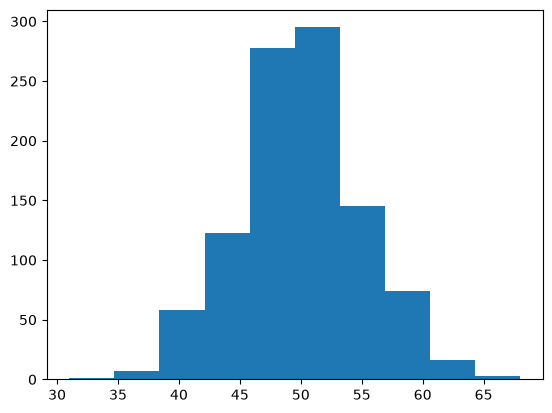

In [54]:
funcao_binomial = np.random.binomial(100,0.5, size= 1000)
plt.hist(funcao_binomial)

Aqui eu apenas usei a função "random.binomial" para gerar uma amostra de binomiais

## 5. Distribuição Multinomial

A distribuição multinomial é uma generalização da distribuição binomial.

Na distribuição binomial, realizamos $n$ lançamentos de uma moeda e contamos quantas vezes ocorreu um dos dois resultados possíveis. Na distribuição multinomial, fazemos a mesma ideia, mas com $k$ resultados possíveis.

Por exemplo, considere um dado de $k$ lados, em que a face $i$ aparece com probabilidade $p_i$, com

$$
p_1+\cdots+p_k=1.
$$

Após $n$ lançamentos, definimos

$$
X=(X_1,\ldots,X_k),
$$

onde $X_i$ representa o número de vezes que a face $i$ apareceu. Nesse caso,

$$
X \sim \mathrm{Multinomial}(n,p_1,\ldots,p_k),
$$

e

$$
X_1+\cdots+X_k=n.
$$

Considere agora um dado de **4 lados** com probabilidades

$$
P(X=1)=0.10,\qquad
P(X=2)=0.20,\qquad
P(X=3)=0.30,\qquad
P(X=4)=0.40.
$$

1. Utilizando o procedimento desenvolvido anteriormente, realize $n$ lançamentos desse dado e conte quantas vezes cada uma das quatro faces apareceu.

In [ ]:
multinomial = []
n = 20
for i in range(n):
    U = np.random.uniform(low=0, high=1)
    if U < 1/10:
        multinomial.append(1)
    elif U < 3/10:
        multinomial.append(2)
    elif U < 6/10:
        multinomial.append(3)
    elif U < 1:
        multinomial.append(4)
print(multinomial)

Aqui eu gerei apenas uma multinomial, com n lançamentos, de um dado de 4 lados viciado

In [ ]:
np.unique(multinomial,return_counts=True)

Aqui eu apenas usei a funcao "unique" para conseguir ver o nro de casos com 2, 3 e 4

2. Repita esse experimento $N$ vezes, gerando uma amostra de tamanho $N$ de vetores com distribuição multinomial.

In [ ]:
nro_de_multinomiais = 100 # tamanho da amostra 
amostra_multinomiais = []
n = 100 # nro de lancamentos de cada multinomial
for j in range(nro_de_multinomiais):
    multinomial = []
    for i in range(n):
        U = np.random.uniform(low=0, high=1)
        if U < 1/10:
            multinomial.append(1)
        elif U < 3/10:
            multinomial.append(2)
        elif U < 6/10:
            multinomial.append(3)
        else:
            multinomial.append(4)
    amostra_multinomiais.append(np.unique(multinomial, return_counts=True)[1])

In [ ]:
nomes_linhas = [f'Amostra {i+1}' for i in range(len(amostra_multinomiais))]

df = pd.DataFrame(
    amostra_multinomiais, 
    columns = ['Face 1', 'Face 2', 'Face 3', 'Face 4'],
    index = nomes_linhas
)
df

Aqui eu gerei uma amostra de 100 multinomiais, sendo que cada multinomial tem como parametro n=100 (pensei em fazer com os dois parametros multiplos de 10, pois quando eu for somar cada caso (como no código abaixo) darem números mais "intuitivos", como para x=4 eu ter aproximadamente 4000 observações)

In [ ]:
somas = np.sum(amostra_multinomiais,axis=0)
somas

In [ ]:
plt.bar([1,2,3,4], somas)
plt.title("Multinomial")
plt.show()

Aqui eu plotei a multinomial em um gráfico de barras para visualizar as frequências absolutas da distribuição

In [ ]:
# funcao_vetorizada = np.vetorize(funcao)
# ensina a funcao a trabalhar com vetor

3. Para cada face $i$, calcule a média amostral de $X_i$ e compare-a com o valor teórico

$$
\mathbb{E}[X_i]=np_i.
$$

In [ ]:
media_teorica_1 = 0.1*n
media_teorica_2 = 0.2*n
media_teorica_3 = 0.3*n
media_teorica_4 = 0.4*n

print(f'As médias teóricas para cada Xi, i = 1,2,3,4, são, respectivamente: {media_teorica_1}, {media_teorica_2}, {media_teorica_3} e {media_teorica_4}. ')

In [ ]:
media_amostral_1 = somas[0]/100
media_amostral_2 = somas[1]/100
media_amostral_3 = somas[2]/100
media_amostral_4 = somas[3]/100

print(f'As médias amostrais para cada Xi, i = 1,2,3,4, são, respectivamente: {media_amostral_1}, {media_amostral_2}, {media_amostral_3} e {media_amostral_4}. ')

Aqui eu calculei as médias amostrais e teóricas de cada Xi, e como pode ser percebido, são muito proximas, como esperado

4. Gere uma segunda amostra utilizando `np.random.multinomial` com os mesmos parâmetros e compare os resultados obtidos pelos dois métodos.

In [ ]:
amostra_funcao_multinomial = np.random.multinomial(n=100, pvals=(0.1,0.2,0.3,0.4), size=100)

df = pd.DataFrame(
    amostra_funcao_multinomial, 
    columns = ['Face 1', 'Face 2', 'Face 3', 'Face 4'],
    index = nomes_linhas
)
df['Total'] = df[['Face 1', 'Face 2', 'Face 3', 'Face 4']].sum(axis=1)
df

In [ ]:
somas_funcao = np.sum(amostra_funcao_multinomial,axis=0)
somas_funcao

As amostras geradas pelos dois métodos são muito parecidas, pois seguem a mesma distribuição com os mesmos parâmetros

5. Verifique que, em cada realização, a soma das contagens das $k$ faces é igual a $n$.

In [ ]:
# para a amostra usando np.random.multinomial
n = 100
contagens = 0
for amostra in amostra_funcao_multinomial:
    if np.sum(amostra) == 100:
        contagens += 1
print(contagens)

In [ ]:
# para a amostra usando loops
n = 100
contagens = 0
for amostra in amostra_multinomiais:
    if np.sum(amostra) == 100:
        contagens += 1
print(f'{contagens} multinomiais da amostra de 100 multinomiais tem 100 lancamentos')

Como todas as multinomiais tem como soma dos lancamentos das k faces igual a 100, sim, são iguai a n, que também é 100

6. Para cada face $i$, calcule a variância amostral de $X_i$ e compare-a com

$$
\operatorname{Var}(X_i)=np_i(1-p_i).
$$

In [ ]:
probs = [0.1,0.2,0.3,0.4]

for prob in probs:
    variancia_teorica = 100*(prob)*(1-prob)
    print(f'Variância teórica da face {prob*10}: {variancia_teorica}')

In [ ]:
amostra_np = np.array(amostra_multinomiais) # Para transformar de lista para um vetor no numpy

In [ ]:
for i in range(4):
    soma_quadrados = np.sum(amostra_np[:,i] ** 2)
    var = (soma_quadrados - (somas[i]**2)/100)/99
    print(f'A variância amostral da face {i} é: {var}')

Aqui eu apenas utilizei um loop para calcular as variâncias tanto amostrais quanto teóricas, e percebe-se que elas estão próximas

7. Escolha duas faces distintas e calcule a covariância amostral entre suas contagens. Compare-a com

$$
\operatorname{Cov}(X_i,X_j)=-np_ip_j.
$$

Interprete o sinal negativo dessa covariância.

In [ ]:
covariancia_teorica = (-1)*(100*0.1*0.2)
covariancia_amostral = np.cov(amostra_np[:,0], amostra_np[:,1])[0,1]

print(f'A covariância teórica é {covariancia_teorica}, e a covariância amostral é {covariancia_amostral}')

Aqui eu calculei a covariância teórica e amostral, que também se mostram próximas. O sinal negativo da covâriancia se da pois há uma relação inversamente proporcional entre o número de vezes que apareceu a face 1 e o número de vezes que apareceu a face 2, já que, em n realizações, quanto mais aparece uma determinada face, menos aparece a outra